# 이진분류 비교 시각화: LightGBM (class_weight) vs LightGBM (downsampling)

이 노트북은 같은 **시간 기준 Train/Test split**에서  
1) **class_weight="balanced"** 로 학습한 LightGBM  
2) **다운사이징(정상 클래스 0 다운샘플링)** 으로 학습한 LightGBM  
을 **같은 Test set**에서 비교합니다.

✅ 사용법  
- 아래 `csv_path`만 본인 경로로 바꾸고 **전체 실행**하면 됩니다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


In [2]:
# =========================
# ✅ 경로만 수정
# =========================
csv_path = r"C:/ai/1month/data/new_flight_weather_merged.csv"

# =========================
# ✅ threshold (보고서용 한 줄 요약에 사용)
# - 아래 비교 그래프는 threshold sweep도 같이 보여줌
# =========================
THR = 0.8


In [3]:
# =====================================================
# 1) 데이터 로드 + 파생변수
# =====================================================
df = pd.read_csv(csv_path)
print("✅ CSV 로드:", len(df))

# 시간 파생
df["departure_datetime"] = pd.to_datetime(df.get("departure_datetime"), errors="coerce")
df = df[df["departure_datetime"].notna()].copy()

df["dep_hour"] = df["departure_datetime"].dt.hour
df["dep_weekday"] = df["departure_datetime"].dt.weekday
df["is_weekend"] = df["dep_weekday"].isin([5, 6]).astype(int)

# ✅ 도착지 코드화: arrival_code
if "arrival_code" in df.columns:
    df["arrival_code"] = (
        pd.to_numeric(df["arrival_code"], errors="coerce")
          .fillna(-1)
          .astype(int)
    )
elif "도착지" in df.columns:
    tmp = pd.to_numeric(df["도착지"], errors="coerce")
    if tmp.notna().mean() > 0.7:
        df["arrival_code"] = tmp.fillna(-1).astype(int)
    else:
        df["arrival_code"] = df["도착지"].astype("category").cat.codes.astype(int)
else:
    print("⚠️ '도착지' 또는 'arrival_code' 컬럼이 없습니다. (arrival_code 생성 스킵)")

# 타깃 체크
if "is_delay" not in df.columns:
    raise KeyError("❌ df에 'is_delay' 컬럼이 없습니다. (0/1 타깃)")


C:\Users\Admin\AppData\Local\Temp\ipykernel_2380\405464246.py:4: DtypeWarning: Columns (31,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✅ CSV 로드: 2836872


In [4]:
# =====================================================
# 2) 컬럼 정의
# =====================================================
num_cols = ["기온(°C)", "풍속_ms", "dep_hour", "dep_weekday", "is_weekend"]
num_cols = [c for c in num_cols if c in df.columns]

cat_cols = ["항공사", "출발지", "flight_type", "arrival_code"]
cat_cols = [c for c in cat_cols if c in df.columns]

X_cols = num_cols + cat_cols

print("✅ num_cols:", num_cols)
print("✅ cat_cols:", cat_cols)
print("✅ X_cols:", X_cols)

# LightGBM categorical 처리
df_lgb = df.copy()
for c in cat_cols:
    df_lgb[c] = df_lgb[c].astype("category")


✅ num_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend']
✅ cat_cols: ['항공사', '출발지', 'flight_type', 'arrival_code']
✅ X_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend', '항공사', '출발지', 'flight_type', 'arrival_code']


In [5]:
# =====================================================
# 3) 시간 기준 Train/Test split
# =====================================================
df_lgb = df_lgb.sort_values("departure_datetime")
split_date = df_lgb["departure_datetime"].quantile(0.8)

train_df = df_lgb[df_lgb["departure_datetime"] <= split_date].copy()
test_df  = df_lgb[df_lgb["departure_datetime"] >  split_date].copy()

X_test = test_df[X_cols]
y_test = test_df["is_delay"].astype(int).values

print("Train:", len(train_df), "Test:", len(test_df))
print("Test 양성(지연=1) 비율:", y_test.mean().round(4))


Train: 2269498 Test: 567374
Test 양성(지연=1) 비율: 0.2578


Train 분포(원본):
0    1933330
1     336168
Name: is_delay, dtype: int64
Train 비율(원본):
0    0.8519
1    0.1481
Name: is_delay, dtype: float64

Train 분포(다운사이징 후):
0    336168
1    336168
Name: is_delay, dtype: int64
Train 비율(다운사이징 후):
0    0.5
1    0.5
Name: is_delay, dtype: float64


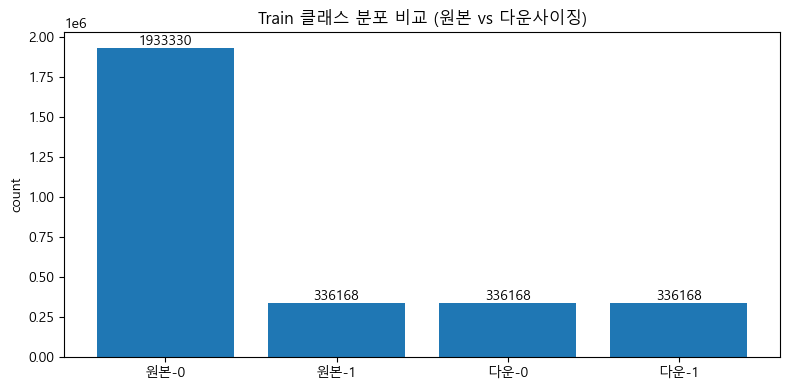

1

In [6]:
# =====================================================
# 4) Train 데이터 분포 확인 + (Downsampling) 만들기
# =====================================================
train_counts = train_df["is_delay"].value_counts().sort_index()
print("Train 분포(원본):")
print(train_counts)
print("Train 비율(원본):")
print((train_counts / train_counts.sum()).round(4))

train_0 = train_df[train_df["is_delay"] == 0]
train_1 = train_df[train_df["is_delay"] == 1]

# 다운사이징: 0을 1 개수만큼 샘플링
if len(train_1) == 0:
    raise ValueError("❌ Train에 양성(1) 샘플이 없습니다. split_date/데이터를 확인하세요.")
if len(train_0) == 0:
    raise ValueError("❌ Train에 음성(0) 샘플이 없습니다. 데이터/타깃을 확인하세요.")

train_0_down = train_0.sample(n=len(train_1), random_state=42)
train_down = pd.concat([train_0_down, train_1]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nTrain 분포(다운사이징 후):")
down_counts = train_down["is_delay"].value_counts().sort_index()
print(down_counts)
print("Train 비율(다운사이징 후):")
print((down_counts / down_counts.sum()).round(4))

# 분포 바차트 (값 라벨 포함)
plt.figure(figsize=(8,4))
vals = [
    train_counts.get(0, 0), train_counts.get(1, 0),
    down_counts.get(0, 0),  down_counts.get(1, 0)
]
labels = ["원본-0","원본-1","다운-0","다운-1"]

bars = plt.bar(labels, vals)

for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(v)}", ha="center", va="bottom")

plt.title("Train 클래스 분포 비교 (원본 vs 다운사이징)")
plt.ylabel("count")
plt.tight_layout()
plt.show()
1

In [7]:
# =====================================================
# 5) 모델 2개 학습
#   A) class_weight balanced
#   B) downsampling
# =====================================================
def make_lgbm(class_weight=None):
    return LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        metric="aucpr",
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

# A) class_weight
X_train_cw = train_df[X_cols]
y_train_cw = train_df["is_delay"].astype(int).values

lgbm_cw = make_lgbm(class_weight="balanced")
lgbm_cw.fit(X_train_cw, y_train_cw, categorical_feature=cat_cols)
print("✅ LGBM(class_weight) 학습 완료")

# B) downsampling
X_train_down = train_down[X_cols]
y_train_down = train_down["is_delay"].astype(int).values

lgbm_down = make_lgbm(class_weight=None)
lgbm_down.fit(X_train_down, y_train_down, categorical_feature=cat_cols)
print("✅ LGBM(downsampling) 학습 완료")


[LightGBM] [Info] Number of positive: 336168, number of negative: 1933330
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 551
[LightGBM] [Info] Number of data points in the train set: 2269498, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
✅ LGBM(class_weight) 학습 완료
[LightGBM] [Info] Number of positive: 336168, number of negative: 336168
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 554
[LightGBM] [Info] Number of data points in the train set: 672336, number of used

In [8]:
# =====================================================
# 6) 예측 확률
# =====================================================
prob_cw   = lgbm_cw.predict_proba(X_test)[:, 1]
prob_down = lgbm_down.predict_proba(X_test)[:, 1]

# 요약표
summary = pd.DataFrame([
    ["LGBM_class_weight", roc_auc_score(y_test, prob_cw),   average_precision_score(y_test, prob_cw)],
    ["LGBM_downsampling", roc_auc_score(y_test, prob_down), average_precision_score(y_test, prob_down)],
], columns=["Model", "ROC-AUC", "PR-AUC"]).sort_values(["ROC-AUC","PR-AUC"], ascending=False).reset_index(drop=True)

display(summary)


,Model,ROC-AUC,PR-AUC
0,LGBM_class_weight,0.702175,0.445909
1,LGBM_downsampling,0.701104,0.444115


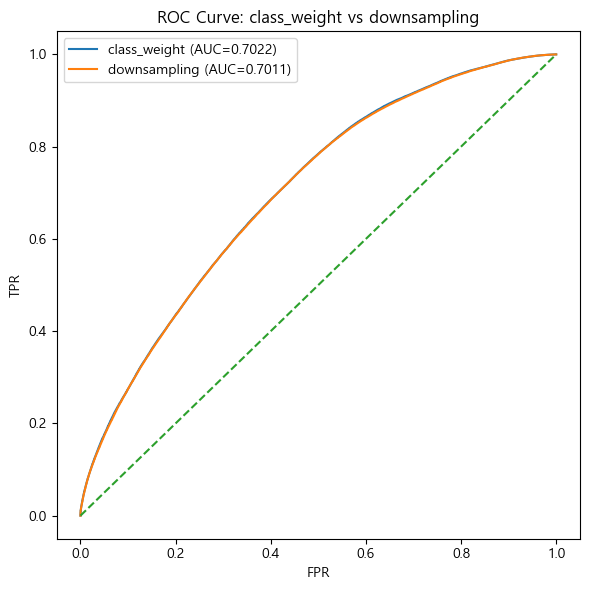

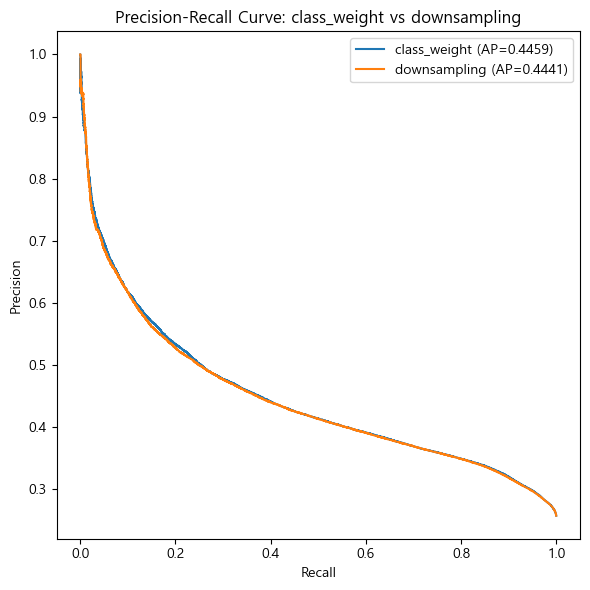

In [9]:
# =====================================================
# 7) ROC Curve / PR Curve 비교
# =====================================================
# ROC
plt.figure(figsize=(6,6))
for name, p in [("class_weight", prob_cw), ("downsampling", prob_down)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve: class_weight vs downsampling")
plt.legend()
plt.tight_layout()
plt.show()

# PR
plt.figure(figsize=(6,6))
for name, p in [("class_weight", prob_cw), ("downsampling", prob_down)]:
    prec, rec, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: class_weight vs downsampling")
plt.legend()
plt.tight_layout()
plt.show()


✅ F1 기준 Best threshold
 - class_weight: 0.39999999999999997
 - downsampling: 0.39999999999999997


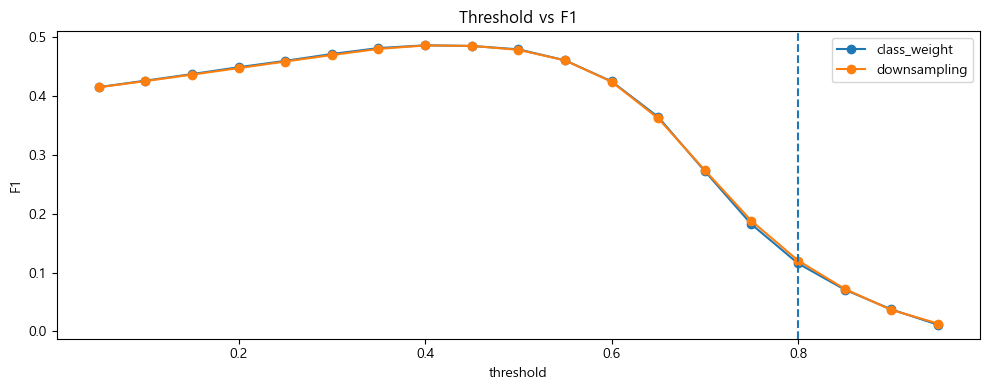

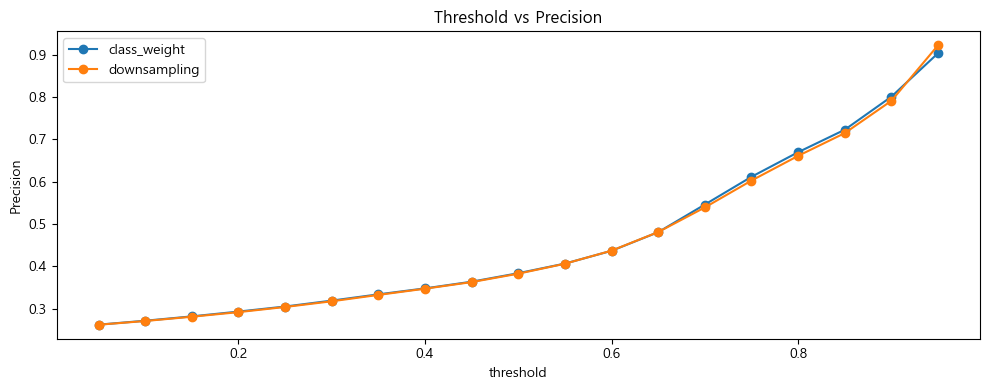

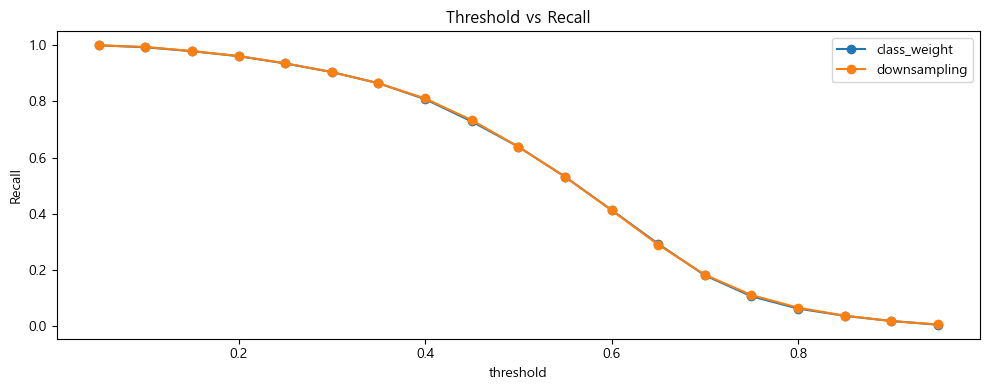

In [10]:
# =====================================================
# 8) Threshold sweep: F1 / Precision / Recall 비교
# =====================================================
def sweep_metrics(y_true, prob, thresholds):
    out = []
    for t in thresholds:
        pred = (prob >= t).astype(int)
        out.append([
            t,
            accuracy_score(y_true, pred),
            precision_score(y_true, pred, zero_division=0),
            recall_score(y_true, pred, zero_division=0),
            f1_score(y_true, pred, zero_division=0),
        ])
    return pd.DataFrame(out, columns=["thr","acc","precision","recall","f1"])

ths = np.linspace(0.05, 0.95, 19)

df_cw   = sweep_metrics(y_test, prob_cw, ths)
df_down = sweep_metrics(y_test, prob_down, ths)

best_cw_thr   = df_cw.loc[df_cw["f1"].idxmax(), "thr"]
best_down_thr = df_down.loc[df_down["f1"].idxmax(), "thr"]

print("✅ F1 기준 Best threshold")
print(" - class_weight:", float(best_cw_thr))
print(" - downsampling:", float(best_down_thr))

plt.figure(figsize=(10,4))
plt.plot(df_cw["thr"], df_cw["f1"], marker="o", label="class_weight")
plt.plot(df_down["thr"], df_down["f1"], marker="o", label="downsampling")
plt.axvline(THR, linestyle="--")   # ✅ 0.8 표시
plt.xlabel("threshold")
plt.ylabel("F1")
plt.title("Threshold vs F1")
plt.legend()
plt.tight_layout()
plt.show()

# Precision 곡선
plt.figure(figsize=(10,4))
plt.plot(df_cw["thr"], df_cw["precision"], marker="o", label="class_weight")
plt.plot(df_down["thr"], df_down["precision"], marker="o", label="downsampling")
plt.xlabel("threshold")
plt.ylabel("Precision")
plt.title("Threshold vs Precision")
plt.legend()
plt.tight_layout()
plt.show()

# Recall 곡선
plt.figure(figsize=(10,4))
plt.plot(df_cw["thr"], df_cw["recall"], marker="o", label="class_weight")
plt.plot(df_down["thr"], df_down["recall"], marker="o", label="downsampling")
plt.xlabel("threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall")
plt.legend()
plt.tight_layout()
plt.show()


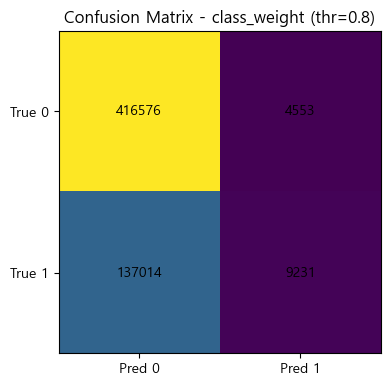

              precision    recall  f1-score   support

           0     0.7525    0.9892    0.8548    421129
           1     0.6697    0.0631    0.1154    146245

    accuracy                         0.7505    567374
   macro avg     0.7111    0.5262    0.4851    567374
weighted avg     0.7312    0.7505    0.6642    567374



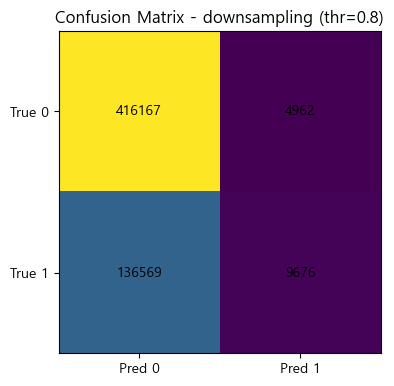

              precision    recall  f1-score   support

           0     0.7529    0.9882    0.8547    421129
           1     0.6610    0.0662    0.1203    146245

    accuracy                         0.7506    567374
   macro avg     0.7070    0.5272    0.4875    567374
weighted avg     0.7292    0.7506    0.6654    567374



In [11]:
# =====================================================
# 9) Confusion Matrix 비교 (THR 기준)
# =====================================================
def plot_cm(y_true, prob, thr, title):
    pred = (prob >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xticks([0,1], ["Pred 0","Pred 1"])
    plt.yticks([0,1], ["True 0","True 1"])
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, pred, digits=4))

plot_cm(y_test, prob_cw, THR, f"Confusion Matrix - class_weight (thr={THR})")
plot_cm(y_test, prob_down, THR, f"Confusion Matrix - downsampling (thr={THR})")


,method,thr,ROC_AUC,PR_AUC,ACC,PREC,RECALL,F1
0,class_weight,0.8,0.702175,0.445909,0.750487,0.669689,0.063120,0.115367
1,downsampling,0.8,0.701104,0.444115,0.750551,0.661019,0.066163,0.120286


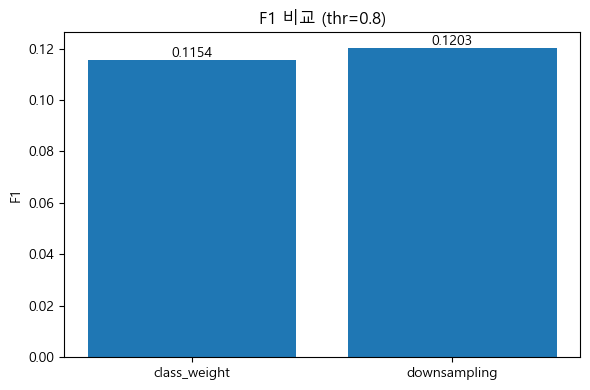

In [12]:
# =====================================================
# 10) (보고서용) 한 줄 요약 박스: ROC/PR + THR 기준 F1
# =====================================================
def metrics_at_thr(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    return {
        "ROC_AUC": roc_auc_score(y_true, prob),
        "PR_AUC": average_precision_score(y_true, prob),
        "ACC": accuracy_score(y_true, pred),
        "PREC": precision_score(y_true, pred, zero_division=0),
        "RECALL": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
    }

m1 = metrics_at_thr(y_test, prob_cw, THR)
m2 = metrics_at_thr(y_test, prob_down, THR)

report = pd.DataFrame([
    ["class_weight", THR, *m1.values()],
    ["downsampling", THR, *m2.values()],
], columns=["method","thr","ROC_AUC","PR_AUC","ACC","PREC","RECALL","F1"])

display(report)

# Bar (F1) with value labels
plt.figure(figsize=(6,4))
bars = plt.bar(report["method"], report["F1"])
for b, v in zip(bars, report["F1"].values):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:.4f}", ha="center", va="bottom")
plt.title(f"F1 비교 (thr={THR})")
plt.ylabel("F1")
plt.tight_layout()
plt.show()
